In [13]:
! pip install opencv-python numpy matplotlib scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [15]:
# Path to your dataset folder
dataset_path = r"C:\Users\reshu\Desktop\ml_Task\Garbage\dataset"

# Map folders to decomposable (0) or non-decomposable (1)
class_mapping = {
    "cardboard": 0, 
    "paper": 0, 
    "glass": 1, 
    "metal": 1, 
    "plastic": 1
}


In [16]:
# Feature extraction function
def extract_features(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (64,64))
    hist = cv2.calcHist([img], [0], None, [32], [0,256])
    hist = hist.flatten() / hist.sum()
    return hist



In [17]:
# Load all images and labels
X, y = [], []
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if folder not in class_mapping:
        continue
    label = class_mapping[folder]
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            X.append(extract_features(fpath))
            y.append(label)
        except:
            continue

X = np.array(X)
y = np.array(y)
print("Data loaded:", X.shape, y.shape)



Data loaded: (2390, 32) (2390,)


In [18]:
# Train Random Forest classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Local ML Accuracy:", accuracy_score(y_test, y_pred))



Local ML Accuracy: 0.8200836820083682


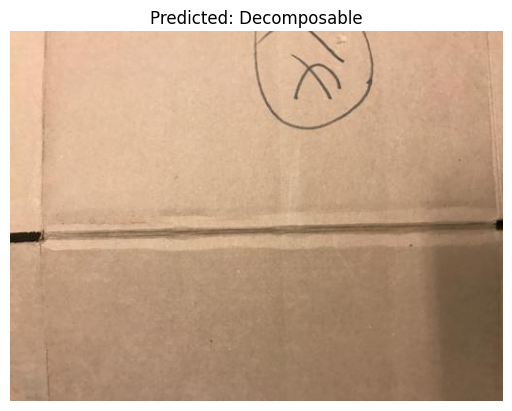

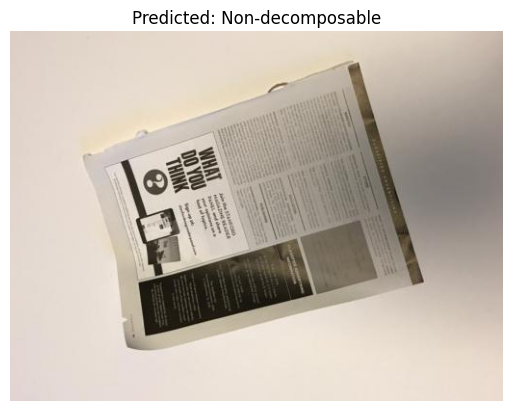

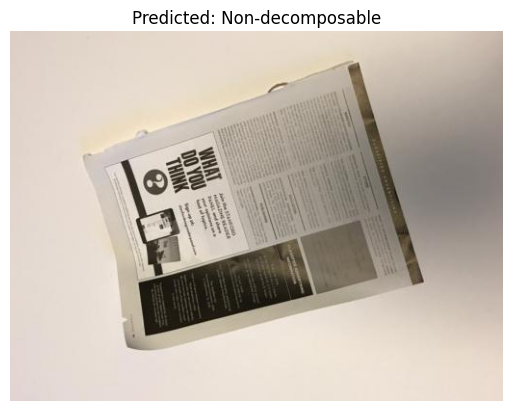

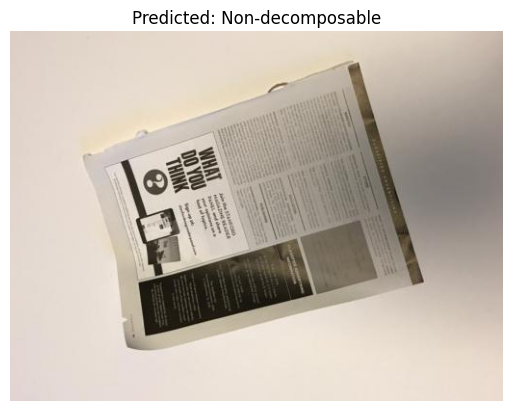

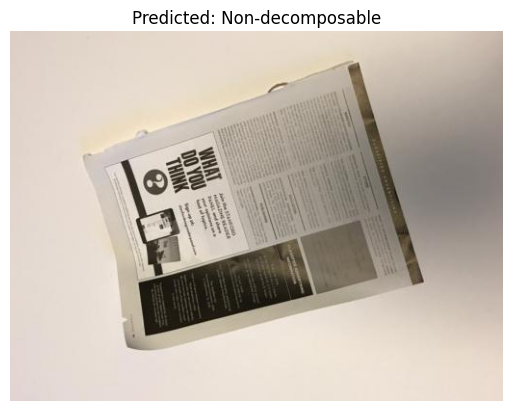

In [19]:
# Optional: Show a few test images with predictions
def show_image_with_prediction(img_path, pred_label):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Predicted: " + ("Decomposable" if pred_label==0 else "Non-decomposable"))
    plt.show()

for i in range(5):
    idx = np.random.randint(0, len(X_test))
    img_file = os.listdir(os.path.join(dataset_path, list(class_mapping.keys())[y_test[idx]]))[0]
    img_path = os.path.join(dataset_path, list(class_mapping.keys())[y_test[idx]], img_file)
    show_image_with_prediction(img_path, y_pred[idx])


In [22]:
all_predictions = model.predict(X)
df = pd.DataFrame({
    "img_path": img_path,
    "predicted_label": ["Decomposable" if p==0 else "Non-decomposable" for p in all_predictions]
})
csv_path = "garbage_predictions.csv"
df.to_csv(csv_path, index=False)
print(f"Predictions saved to {csv_path}")


Predictions saved to garbage_predictions.csv
